In [2]:
import pandas as pd

rules_path = "../../data/Georgios/pcy_recommender/rules_dedup.csv"
# ή το αντίστοιχο path στο repo σας
df_rules = pd.read_csv(rules_path)

# Βεβαιώσου ότι είναι numeric
df_rules["confidence_A_to_B"] = pd.to_numeric(df_rules["confidence_A_to_B"], errors="coerce")
df_rules["lift"] = pd.to_numeric(df_rules["lift"], errors="coerce")


In [11]:
param_grid = [
    (0.001, 1.0),
    (0.001, 1.2),
    (0.005, 1.0),
    (0.005, 1.2),
    (0.010, 1.0),
    (0.010, 1.2),
    (0.030, 1.0),
    (0.030, 1.2),
    (0.050, 1.2),
    (0.050, 1.5),
]

In [12]:
rows = []
for min_conf, min_lift in param_grid:
    df_filt = df_rules[
        (df_rules["confidence_A_to_B"] >= min_conf) &
        (df_rules["lift"] >= min_lift)
    ]
    rows.append({
        "min_conf": min_conf,
        "min_lift": min_lift,
        "n_rules": len(df_filt),
        "mean_lift": df_filt["lift"].mean(),
    })

summary = pd.DataFrame(rows)
display(summary)


,min_conf,min_lift,n_rules,mean_lift
0,0.001,1.0,74,2.308974
1,0.001,1.2,69,2.393972
2,0.005,1.0,74,2.308974
3,0.005,1.2,69,2.393972
4,0.010,1.0,74,2.308974
5,0.010,1.2,69,2.393972
6,0.030,1.0,74,2.308974
7,0.030,1.2,69,2.393972
8,0.050,1.2,60,2.519075
9,0.050,1.5,59,2.538641


In [13]:
summary = pd.DataFrame(rows)

summary_styled = (
    summary.style
    .format({"min_conf": "{:.2f}", "min_lift": "{:.1f}", "mean_lift": "{:.3f}"})
    .highlight_max(subset=["n_rules", "mean_lift"], color="#d4f4dd")
    .set_caption("PCY rule filtering: min_conf / min_lift grid")
)

display(summary_styled)


,min_conf,min_lift,n_rules,mean_lift
0,0.00,1.0,74,2.309
1,0.00,1.2,69,2.394
2,0.01,1.0,74,2.309
3,0.01,1.2,69,2.394
4,0.01,1.0,74,2.309
5,0.01,1.2,69,2.394
6,0.03,1.0,74,2.309
7,0.03,1.2,69,2.394
8,0.05,1.2,60,2.519
9,0.05,1.5,59,2.539


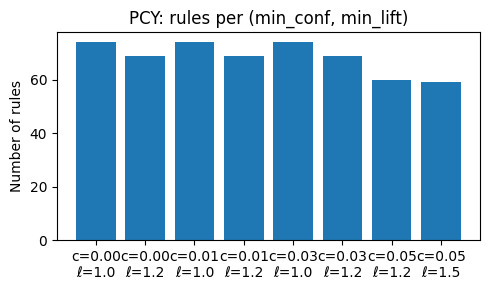

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(
    [f"c={c:.2f}\nℓ={l:.1f}" for c, l in zip(summary["min_conf"], summary["min_lift"])],
    summary["n_rules"],
)
plt.ylabel("Number of rules")
plt.title("PCY: rules per (min_conf, min_lift)")
plt.tight_layout()
plt.show()
